# 🧬 RSG Brazil 2026 — Análise de Variantes em Bioinformática

Este notebook faz parte do minicurso **“Análise de Variantes em Bioinformática”**, oferecido no **RSG Brazil 2026**, com foco em aplicações práticas voltadas à **genômica humana e oncogenômica**.

Ao longo deste material, serão abordados os principais passos de um pipeline de análise de variantes, desde o processamento inicial dos dados de sequenciamento até a interpretação biológica dos resultados. Essas etapas são fundamentais para aplicações em **pesquisa translacional**, **diagnóstico molecular** e **medicina de precisão**, especialmente no contexto do câncer. Este material foi desenvolvido pela equipe do projeto Oncogensus (https://oncogensus.org/index) e está disponível em neste [LINK.](https://github.com/oncogensus/Curso-RSG-Brazil)

---

## 🎯 Objetivos do minicurso

Ao final deste treinamento, espera-se que o participante seja capaz de:

- Compreender o fluxo geral de análise de variantes em dados de NGS  
- Executar etapas essenciais de um pipeline bioinformático  
- Interpretar resultados de forma crítica no contexto biológico  

---

## 📚 Conteúdo abordado

- Instalação e configuração de ferramentas bioinformáticas  
- Download de dados de sequenciamento e genoma de referência  
- Controle de qualidade (QC) de dados de NGS  
- Alinhamento de leituras ao genoma de referência  
- Chamada de variantes (*variant calling*)  
- Anotação funcional e interpretação de variantes  

---

## 🚀 Uma breve introdução ao ambiente Google Colab

O **Google Colab (Colaboratory)** é um ambiente de computação em nuvem gratuito que permite executar código Python diretamente no navegador, sem necessidade de instalação ou configuração local. Ele é amplamente utilizado em áreas como ciência de dados, aprendizado de máquina e bioinformática.

🚀 Principais vantagens

- 🌐 **Acesso via navegador**: não requer instalação — funciona em qualquer sistema operacional  
- 💻 **Ambiente pré-configurado**: já vem com diversas bibliotecas científicas (NumPy, Pandas, Matplotlib, etc.)  
- ☁️ **Integração com Google Drive**: facilita salvar, compartilhar e versionar notebooks  
- 🤝 **Colaboração em tempo real**: semelhante ao Google Docs, permitindo múltiplos usuários  

🛠️ Funcionalidades principais

- 📓 **Notebooks interativos**: combinação de código, texto (Markdown), imagens e gráficos  
- ▶️ **Execução célula a célula**: facilita testes, depuração e ensino  
- 📦 **Gerenciamento de pacotes**: instalação de bibliotecas via `pip` ou `apt` diretamente no notebook  
- 📊 **Visualização de dados**: suporte nativo para gráficos e outputs interativos  
- 🔗 **Integração com GitHub**: permite abrir e salvar notebooks diretamente em repositórios  

🎯 Aplicações comuns

- Análise de dados e estatística  
- Machine Learning e Deep Learning  
- Processamento de dados genômicos  
- Ensino e demonstrações interativas

💡 **Observações**

O Google Colab executa códigos principalmente em **Python**, porém também permite rodar comandos diretamente no sistema operacional (Linux) que está por trás do ambiente.

Para isso, basta adicionar o símbolo `!` antes do comando. Dessa forma, você pode executar instruções de terminal, como instalação de pacotes, manipulação de arquivos e execução de ferramentas externas.

**Exemplo:**
```bash
!ls
!pip install numpy
```
É possível ainda acessar o terminal linux através do ícone **Terminal** no canto inferior esquerdo.

A seguir, iniciaremos com a **instalação das bibliotecas e ferramentas** necessárias para a execução das análises ao longo do minicurso.

# Instalação do gerenciador de pacotes e ambiente virtuais mamba



Aqui será instalado o **Mamba**, uma ferramenta moderna para **gerenciamento de pacotes e ambientes computacionais**, amplamente utilizada em bioinformática.

O **Mamba**  resolve automaticamente as dependências entre programas, escolhe versões compatíveis e realiza a instalação de forma rápida e eficiente, utilizando um mecanismo otimizado de resolução de dependências.

👉 **Em resumo:** organiza ambientes isolados e instala softwares de forma rápida, garantindo compatibilidade entre eles.

No contexto deste minicurso, o uso do Mamba permite:

- ⚡ Instalações mais rápidas no Colab  
- 🔬 Facilidade na instalação de ferramentas bioinformáticas  
- 🔁 Reprodutibilidade das análises  

---

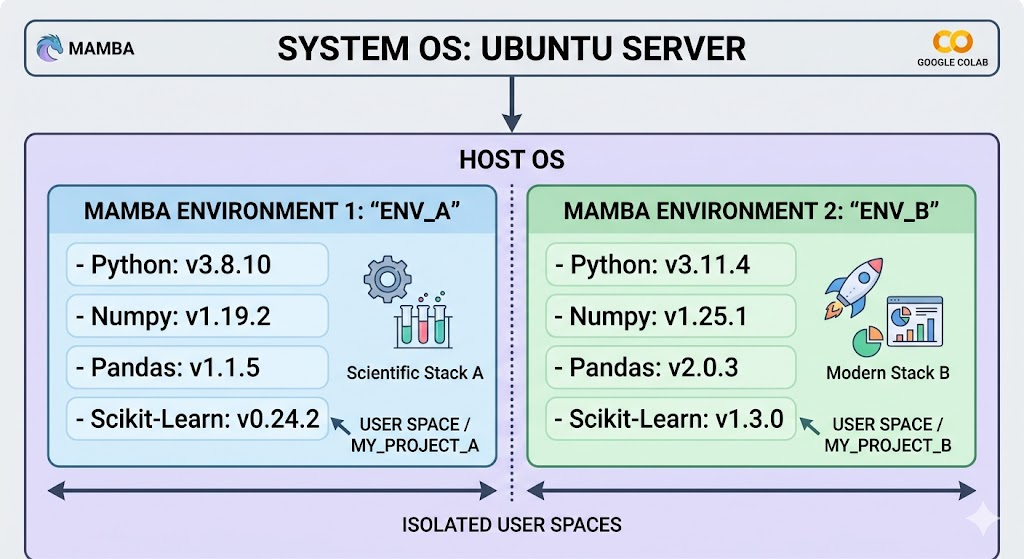

 ⚙️ **Instalação**

Como o ambiente do Google Colab é executa em **Python**, utilizaremos o **PIP** para instalar o Mamba na sessão atual.

- **PIP**: Gerenciador de pacotes Python   
- **Mamba**: Gerenciador de pacotes e ambientes computacionais

---

 📚 **Referências**

- https://docs.conda.io/en/latest/  
- https://mamba.readthedocs.io/en/latest/user_guide/mamba.html  
- https://pip.pypa.io  



In [ ]:
#Usando instalador de bibliotecas do Python (pip) para instalar o conda/mamba.
# Conda/Mamba é uma ferramenta que permite o gerenciamento de pacotes e ambientes.
# Que é um espaço isolado onde você pode instalar e executar ferramentas específicas para um projeto
!pip install --upgrade --force-reinstall zstandard
!pip install -q condacolab

#Código em Python
import condacolab
condacolab.install()

# Abaixo removemos pins de versão do python para evitar conflitos
!sed -i '/cudatoolkit/d' /usr/local/conda-meta/pinned
!sed -i '/python/d' /usr/local/conda-meta/pinned


#Instala algumas dependências necessárias para os próximos passos
#conda-forge é um canal comunitário em que ficam ferramentas e pacotes
#bioconda é um canal especializado em bioinfomática
!mamba install -c conda-forge curl --quiet


#Lista os softwares do ambiente atual do conda/mamba
!mamba env list

#Baixando o genoma de referência e sequências de interesse



🔎 **Entrez (NCBI)**

O **Entrez** é um sistema integrado de busca e recuperação de informações biológicas disponibilizado pelo **NCBI (National Center for Biotechnology Information)**.

Ele permite acessar, de forma unificada, diversos bancos de dados relevantes para bioinformática, incluindo:

- 🧬 Sequências de DNA e proteínas  
- 📚 Artigos científicos (PubMed)  
- 🧪 Genomas completos  
- 🧱 Estruturas tridimensionais de biomoléculas  
- 🧬 Variantes genéticas  

Essa integração facilita a exploração e a correlação de dados biológicos a partir de uma única interface.

---

⚙️ **Configuração do ambiente**

A seguir, criaremos um novo ambiente utilizando o **Mamba** para instalar e utilizar ferramentas associadas ao Entrez.

---

📖 **Mais informações**

- 🔗 [Acessar o Entrez](https://www.ncbi.nlm.nih.gov/search/)  
- 📘 [Manual do Entrez (NCBI Bookshelf)](https://www.ncbi.nlm.nih.gov/books/NBK3837/)

In [ ]:
# 🔧 Criando ambiente para baixar o genoma de referência e anotações
# Criar o ambiente
!mamba create -n entrez_ncbi -y -q
# Listar ambientes (opcional)
!mamba env list
# Instalar pacotes diretamente no ambiente correto
!mamba install -n entrez_ncbi -c bioconda cmake entrez-direct -y -q
# Verificando as vers±oes instaladas
!mamba list -n entrez_ncbi entrez-direct

📁 **Preparando diretório e genoma de referência**

Nesta etapa, vamos criar a pasta **`refGen`**, que será utilizada para armazenar o genoma de referência e seus arquivos associados.

Em seguida, realizaremos o download do genoma, que servirá como base para as análises posteriores.

In [ ]:
# O comando mkdir em shell é utilizado para criar pastas.
# Já o comando pwd mostra o caminho do diretório local enquanto o comando ls lista arquivos e diretórios
!echo -e "### Criando a pasta dados\n"
!mkdir refGen
!echo -e "### O diretório atual é: $PWD \n"
!echo -e "### O conteúdo de \"$PWD\" é:\n"
!ls -lh

🧬 **Download do cromossomo 17 (GRCh38)**

Agora vamos baixar o **cromossomo 17** do genoma de referência **GRCh38**.

Para fins didáticos, utilizaremos apenas um cromossomo em vez do genoma completo, pois isso torna a análise **mais leve e rápida de executar no Google Colab**, sem comprometer o entendimento das etapas do pipeline.

Esse cromossomo será utilizado como **genoma de referência** nas análises seguintes.

In [ ]:
# Mensagem informativa
!echo -e "### Baixando o cromossomo 17\n"

# Executa o esearch + efetch dentro do ambiente mamba 'entrez_ncbi'
# bash -c é necessário para permitir o uso de pipe (|) e redirecionamento (>)
!mamba run -n entrez_ncbi bash -c 'esearch -db nucleotide -query "NC_000017.11" | efetch -format fasta > ./refGen/chr17_GRCh38.fasta'

# Mensagem informativa
!echo -e "### Verificando o arquivo baixado\n"

# Lista o arquivo baixado
!ls -lh ./refGen

📥 **Download dos dados de sequenciamento e base de anotação**

Nesta etapa, vamos baixar os arquivos de **dados de sequenciamento** que serão utilizados nas análises, juntamente com uma **minibase de dados baseada no ClinVar**, que será empregada na **anotação de variantes**.

Serão utilizados três conjuntos de dados referentes ao gene humano **BRCA1**:

- 🧬 Uma sequência de referência (sem mutações)  
- ⚠️ Duas sequências contendo mutações conhecidas  

Esses dados permitirão demonstrar, de forma prática, como variantes genéticas podem ser identificadas e interpretadas.

---

📖 **Mais informações**

- 🔗 [Sobre o gene BRCA1](https://www.cancer.gov/about-cancer/causes-prevention/genetics/brca-fact-sheet)

In [ ]:
# 🔽 Baixando dados de sequenciamento do repositório GitHub para uso nas análises
!echo -e "\n### Baixando as sequências de interesse do GitHub para a pasta dados"
# 🔍 Verifica se o Git está disponível no ambiente
!git --version
# 📦 Clona o repositório contendo os arquivos do gene BRCA1 para a pasta local "brca1"
!git clone https://github.com/oncogensus/Curso-RSG-Brazil.git ./brca1



#Análise de qualidade de dados em sequenciamento Illumina - formato Fastq

🔁 **Recapitulação Teórica: Formato FASTQ**

Todos os sequenciadores modernos geram dados no formato **FASTQ**, que é o padrão para armazenamento de leituras de sequenciamento juntamente com suas qualidades.

Cada sequência no arquivo FASTQ é representada por **4 linhas**, conforme o exemplo abaixo:

```
@SEQ_ID                   # Identificador da sequência
AGCGTGTACTGTGCATGTCGATG   # Sequência de nucleotídeos
+                         # Separador
%%).1***-+*''))**55CCFF   # Qualidade (codificada em ASCII - Phred)
```

🔍 **Interpretação das linhas:**
- **Linha 1:** Identificador da leitura  
- **Linha 2:** Sequência de bases (A, T, C, G)  
- **Linha 3:** Separador (geralmente "+")  
- **Linha 4:** Qualidade de cada base codificada em caracteres ASCII  

---

📊 **Qualidade das Sequências (Phred Score)**

A qualidade das bases é representada por caracteres ASCII, que correspondem a valores numéricos de qualidade **Phred**.

📎 Saiba mais sobre ASCII: https://pt.wikipedia.org/wiki/ASCII  
📎 Explicação detalhada de qualidade: https://help.basespace.illumina.com/files-used-by-basespace/quality-scores  

Os valores de **Phred** indicam a probabilidade de erro na identificação da base:

| Phred | Probabilidade de erro | Acurácia |
|------|----------------------|---------|
| 10   | 1 em 10              | 90%     |
| 20   | 1 em 100             | 99%     |
| 30   | 1 em 1.000           | 99,9%   |
| 40   | 1 em 10.000          | 99,99%  |
| 50   | 1 em 100.000         | 99,999% |
| 60   | 1 em 1.000.000       | 99,9999%|

💡 **Resumo:** Quanto maior o valor de Phred, maior a confiabilidade da base sequenciada.

🔬 **Explorando os arquivos FASTQ**

Nesta etapa, vamos examinar a estrutura dos arquivos de sequenciamento no formato **FASTQ** recém baixados, entendendo como as informações de sequência e qualidade estão organizadas.

In [ ]:
# Exibe as primeiras linhas do arquivo FASTQ compactado (BRCA1_WT_R1) para visualizar sua estrutura (identificador, sequência e qualidade)
!echo -e "### Abrindo o começo do arquivo BRCA1_WT_R1.fq.gz\n"
!zcat ./brca1/BRCA1_WT_R1.fq.gz | head

📊 **Análise de Qualidade com FastQC**

Visualizar diretamente arquivos **FASTQ** não é uma forma prática ou intuitiva de avaliar a qualidade dos dados de sequenciamento.  

Para facilitar essa análise, utilizaremos o **FastQC**, uma ferramenta amplamente usada para gerar relatórios detalhados de qualidade de forma visual e interpretável.

Com o FastQC, é possível avaliar rapidamente aspectos como:
- Qualidade das bases ao longo das leituras  
- Conteúdo GC  
- Presença de adaptadores  
- Distribuição de sequências  

---

🔗 **Mais informações sobre o FastQC:**  
- https://www.bioinformatics.babraham.ac.uk/projects/fastqc/

In [ ]:
# 🔧 Criando ambiente com Mamba e instalando ferramentas de QC

# Criar o ambiente já com os pacotes necessários
!mamba create -n quality -c bioconda fastqc multiqc -y -q

# Listar ambientes (opcional, para conferência)
!mamba env list

# Verificando as vers±oes instaladas
!mamba list -n quality fastqc
!mamba list -n quality multiqc

📊 **Gerando relatório de qualidade com o FastQC e agregando os Relatórios com MultiQC**

Após executar o **FastQC** em todas as amostras, podemos utilizar o **MultiQC** para reunir os resultados em um único relatório consolidado. Isso facilita a visualização e a comparação dos principais indicadores de qualidade entre as amostras analisadas.

O código abaixo realiza as seguintes etapas:

- 📂 Lista os arquivos de entrada na pasta `brca1`
- 🧪 Executa o **FastQC** para cada arquivo `.fq.gz`
- 📁 Armazena os relatórios individuais na pasta `fastqc`
- 📊 Executa o **MultiQC** para agregar os resultados do FastQC
- 🗂️ Salva o relatório consolidado na pasta `multiqc`

Essa abordagem torna a inspeção dos dados mais prática e organizada, especialmente quando trabalhamos com múltiplas amostras.

In [ ]:
# Executando o FastQC nos arquivos FASTQ e agregando os resultados com MultiQC

!echo -e "### Listando arquivos na pasta brca1 \n"
!ls ./brca1/

!echo -e "\n### Criando a pasta fastqc para armazenar os relatórios do FastQC \n"
!mkdir -p fastqc

!echo -e "\n### Rodando o FastQC no ambiente mamba para os arquivos da pasta brca1 \n"
!mamba run -n quality fastqc ./brca1/*.fq.gz -o ./fastqc

!echo -e "\n### Listando os arquivos gerados pelo FastQC \n"
!ls ./fastqc

!echo -e "\n### Criando a pasta multiqc para armazenar o relatório consolidado \n"
!mkdir -p multiqc

!echo -e "\n### Rodando o MultiQC para agregar os relatórios do FastQC \n"
!mamba run -n quality multiqc ./fastqc -o ./multiqc

!echo -e "\n### Listando os arquivos gerados pelo MultiQC \n"
!ls ./multiqc

📊 **Visualização e Filtragem da Qualidade das Sequências**

Agora vamos **visualizar os resultados do FastQC e MultiQC**, realizando o download dos arquivos `.html` gerados. Esses relatórios permitem uma inspeção detalhada da qualidade das leituras de sequenciamento.  

Em seguida, partiremos para uma etapa fundamental: a **filtragem de sequências de baixa qualidade** 🧹  

Essa etapa é essencial para garantir maior **confiabilidade nas análises downstream**, como alinhamento e chamada de variantes. Para isso, utilizaremos a ferramenta **fastp**, que realiza:

- ✂️ Remoção de bases de baixa qualidade  
- 🧬 Filtragem de reads ruins  
- ⚙️ Processamento rápido e eficiente  

🔗 **Mais informações sobre o fastp:**  
- [fastp](https://github.com/OpenGene/fastp)

In [ ]:
# Instalando o fastp no ambiente "quality" com mamba
# O parâmetro "-y" confirma automaticamente a instalação e "--quiet" reduz a saída no terminal

!echo -e "\n### Instalando o fastp no ambiente quality \n"
!mamba install -n quality -c bioconda fastp -y --quiet

# Verificando se o fastp foi instalado corretamente no ambiente
!mamba list -n quality fastp

✂️ **Filtragem de Sequências com fastp**

Agora vamos utilizar o **fastp**, recém-instalado no ambiente, para realizar a **filtragem e o pré-processamento das sequências** 🧬  

Essa etapa é fundamental para melhorar a qualidade dos dados antes das análises posteriores. Com isso, garantimos um conjunto de dados mais limpo e confiável para as próximas etapas da análise.

In [ ]:
# ✂️ Filtragem de sequências com fastp (trimagem)
# Nesta etapa, utilizamos o fastp dentro do ambiente "quality" para:
# - Remover bases de baixa qualidade
# - Detectar e remover adaptadores automaticamente
# - Gerar arquivos FASTQ filtrados ("trimados")
# - Produzir relatórios HTML com métricas de qualidade

!echo -e "\n### Criando a pasta 'trimmed' para armazenar os arquivos filtrados \n"
!mkdir -p trimmed

!echo -e "\n### Iniciando a filtragem das sequências com fastp (Q≥20) \n"

# 🧬 Amostra controle (WT)
!mamba run -n quality fastp \
-i ./brca1/BRCA1_WT_R1.fq.gz \
-I ./brca1/BRCA1_WT_R2.fq.gz \
--detect_adapter_for_pe \
-o ./trimmed/BRCA1_WT_R1_Trim.fq.gz \
-O ./trimmed/BRCA1_WT_R2_Trim.fq.gz \
-h ./trimmed/BRCA1_WT_Trim.html \
--qualified_quality_phred 20

# 🧬 Mutação 185delAG
!mamba run -n quality fastp \
-i ./brca1/BRCA1_185delAG_R1.fq.gz \
-I ./brca1/BRCA1_185delAG_R2.fq.gz \
--detect_adapter_for_pe \
-o ./trimmed/BRCA1_185delAG_R1_Trim.fq.gz \
-O ./trimmed/BRCA1_185delAG_R2_Trim.fq.gz \
-h ./trimmed/BRCA1_185delAG_Trim.html \
--qualified_quality_phred 20

# 🧬 Mutação c.5266dupC
!mamba run -n quality fastp \
-i ./brca1/BRCA1_c.5266dupC_R1.fq.gz \
-I ./brca1/BRCA1_c.5266dupC_R2.fq.gz \
--detect_adapter_for_pe \
-o ./trimmed/BRCA1_c.5266dupC_R1_Trim.fq.gz \
-O ./trimmed/BRCA1_c.5266dupC_R2_Trim.fq.gz \
-h ./trimmed/BRCA1_c.5266dupC_Trim.html \
--qualified_quality_phred 20

# ⚠️ Teste mais rigoroso: aumentando o limiar de qualidade para Q≥35 (apenas para WT)
!echo -e "\n### Reprocessando BRCA1_WT com filtro mais rigoroso (Q≥35) \n"

!mamba run -n quality fastp \
-i ./brca1/BRCA1_WT_R1.fq.gz \
-I ./brca1/BRCA1_WT_R2.fq.gz \
--detect_adapter_for_pe \
-o ./trimmed/BRCA1_WT_R1_Trim35.fq.gz \
-O ./trimmed/BRCA1_WT_R2_Trim35.fq.gz \
-h ./trimmed/BRCA1_WT_Trim35.html \
--qualified_quality_phred 35

📊 **Visualização dos Relatórios do fastp**

Nesta etapa, vamos **visualizar os relatórios interativos gerados pelo fastp** 🧬  

Esses arquivos `.html` contêm informações detalhadas sobre a qualidade das leituras **antes e após a filtragem**, permitindo uma avaliação clara do impacto da trimagem.

Com esse relatório, você pode explorar:

- 📈 Distribuição de qualidade das bases  
- 🔍 Conteúdo de GC  
- ✂️ Bases removidas durante a filtragem  
- ⚡ Comparação *before vs after filtering*  

💡 *A visualização direta no Colab facilita a inspeção rápida dos dados sem necessidade de download.*  

➡️ Abaixo, exibimos o relatório HTML de uma das amostras processadas.

In [ ]:
#Visualizando o relatório gerado pelo fastp
!pwd
import IPython
#IPython.display.HTML(open('./trimmed/ERR5761182.fastp.html').read())
IPython.display.HTML('./trimmed/BRCA1_WT_Trim35.html')

#Alinhamento das leituras de sequenciamento contra um genoma de referência

🧬 **Alinhamento de Sequências com BWA**

Agora vamos iniciar a instalação do **BWA (Burrows-Wheeler Aligner)**, uma das principais ferramentas utilizadas para **alinhamento de sequências contra um genoma de referência** 🧪  

O BWA é amplamente empregado em análises de NGS, sendo essencial para etapas como:

- 🔗 Alinhamento de reads ao genoma de referência  
- 🧬 Preparação dos dados para chamada de variantes  
- ⚙️ Processamento eficiente de grandes volumes de dados  

💡 *Essa etapa é fundamental no pipeline de análise, pois conecta as leituras obtidas no sequenciamento ao genoma de interesse.*

🔗 **Mais informações sobre o BWA:**  
- [BWA](https://github.com/lh3/bwa)

In [ ]:
# 🧬 Criando e configurando o ambiente "bwa" com mamba
!echo -e "\n### Criando o ambiente bwa \n"
!mamba create -n bwa -y

!echo -e "\n### Instalando o BWA no ambiente bwa \n"
!mamba install -n bwa -c bioconda bwa -y --quiet

# 🔍 Verificando se o BWA foi instalado corretamente
!mamba list -n bwa bwa

🧬 **Indexação do Genoma de Referência com BWA**

Antes de realizar o alinhamento das sequências, é necessário **indexar o genoma de referência** 📚  

A indexação cria estruturas auxiliares que permitem ao **BWA** localizar rapidamente regiões semelhantes entre as leituras e o genoma, tornando o processo de alinhamento muito mais eficiente ⚡  

Nesta etapa, iremos:

- 🧬 Gerar o índice do genoma `chr17_GRCh38.fasta`  
- 📂 Criar uma pasta para armazenar os resultados do alinhamento  

💡 *Essa etapa é obrigatória e realizada apenas uma vez para cada genoma de referência.*

In [ ]:
# 🧬 Criando o índice do genoma de referência com BWA
!echo -e "\n### Indexando o genoma de referência \n"
!mamba run -n bwa bwa index -p ./refGen/chr17_GRCh38 ./refGen/chr17_GRCh38.fasta

# 📂 Criando pasta para armazenar arquivos pós-alinhamento
!echo -e "\n### Criando pasta para resultados do alinhamento \n"
!mkdir -p aligned

🔗 **Alinhamento das Sequências ao Genoma de Referência**

Com o genoma de referência devidamente **indexado**, podemos agora realizar o **alinhamento das leituras de sequenciamento** 🧬  

Nesta etapa, as sequências de interesse serão comparadas ao genoma de referência, permitindo identificar **onde cada read se origina** 🔍  

Esse processo é fundamental para:

- 📍 Determinar a posição das leituras no genoma  
- 🧬 Detectar variações genéticas (mutações)  
- ⚙️ Preparar os dados para etapas posteriores, como chamada de variantes  

💡 *O alinhamento é uma das etapas centrais na análise de dados de sequenciamento.*

In [ ]:
# 🚀 Alinhando as leituras trimadas contra o genoma de referência com BWA
!echo -e "\n### Alinhando as sequências BRCA1 contra o genoma de referência\n"

!mamba run -n bwa bwa mem \
-R "@RG\tID:BRCA1_WT\tSM:BRCA1_WT\tPL:ILLUMINA" \
./refGen/chr17_GRCh38 \
./trimmed/BRCA1_WT_R1_Trim.fq.gz \
./trimmed/BRCA1_WT_R2_Trim.fq.gz \
-o ./aligned/BRCA1_WT.bam

!mamba run -n bwa bwa mem \
-R "@RG\tID:BRCA1_185delAG\tSM:BRCA1_185delAG\tPL:ILLUMINA" \
./refGen/chr17_GRCh38 \
./trimmed/BRCA1_185delAG_R1_Trim.fq.gz \
./trimmed/BRCA1_185delAG_R2_Trim.fq.gz \
-o ./aligned/BRCA1_185delAG.bam

!mamba run -n bwa bwa mem \
-R "@RG\tID:BRCA1_c.5266dupC\tSM:BRCA1_c.5266dupC\tPL:ILLUMINA" \
./refGen/chr17_GRCh38 \
./trimmed/BRCA1_c.5266dupC_R1_Trim.fq.gz \
./trimmed/BRCA1_c.5266dupC_R2_Trim.fq.gz \
-o ./aligned/BRCA1_c.5266dupC.bam

🧰 **Manipulação de arquivos de alinhamento com Samtools**

Para tratar os arquivos gerados na etapa de alinhamento, utilizaremos o **Samtools**, uma ferramenta essencial e amplamente utilizada em bioinformática para manipulação e análise de dados de sequenciamento de DNA 🧬.

Com o **Samtools**, é possível:

- 📦 Converter arquivos entre formatos (**SAM ↔ BAM**)  
- 🔃 Ordenar leituras de acordo com a posição no genoma  
- 🧭 Indexar arquivos para acesso rápido  
- 📊 Gerar estatísticas e avaliar a qualidade dos alinhamentos  

---

🔗 **Mais informações**

- 🌐 [Github/Samtools](https://github.com/samtools/samtools)  
- 📘 [Manual oficial](https://www.htslib.org/doc/samtools.html)

In [ ]:
# 🧰 Criando ambiente para análise de alinhamento com Samtools
!echo -e "\n### Criando ambiente samtools\n"
!mamba create -n samtools -c conda-forge -c bioconda samtools -y --quiet

# 🔍 Verificando ambiente criado
!mamba env list

# 📊 Testando instalação do Samtools
!mamba list -n samtools samtools

🧬 Processamento dos arquivos de alinhamento com Samtools

Nesta etapa, utilizaremos o **Samtools** para tratar os arquivos gerados no alinhamento 📊.

Usaremos para:
- 📦 **Converter os arquivos entre os formatos SAM e BAM**  
- 🔃 **Ordenar as reads alinhadas**, organizando-as de acordo com sua posição no genoma  
- 🧭 **Indexar os arquivos**, permitindo acesso rápido a regiões específicas  

Esses passos são essenciais para preparar os dados para análises posteriores, como a chamada de variantes 🧪. Abaixo vamos verificar a falta de ordem em um dos arquivos bam gerado na etapa anterior

In [ ]:
# Imprime as primeiras leituras do arquivo BAM DESORDENADO
!mamba run -n samtools samtools view ./aligned/BRCA1_WT.bam | sed -n '1,10p'

🧬 **Interpretação de reads pareadas (paired-end)**

Exemplo de duas linhas do arquivo BAM:

NG_005905.2-25820   99   NC_000017.11   43118354   60   150M   =   43118405   201

NG_005905.2-25820   147  NC_000017.11   43118405   60   150M   =   43118354  -201

🔗 O que essas linhas representam?

👉 Essas duas linhas correspondem a um **par de reads (paired-end)** da mesma molécula de DNA.



🧩 **Primeira read (FLAG 99)**

- 🏷️ **QNAME**: identificador da read (mesmo nas duas linhas)  
- ⚙️ **FLAG 99**: primeira read do par, alinhada corretamente, fita forward ➡️  
- 🧭 **RNAME**: cromossomo 17  
- 📍 **POS**: posição inicial (43.118.354)  
- 📊 **MAPQ = 60**: alinhamento de alta qualidade  
- 🧩 **CIGAR = 150M**: 150 bases alinhadas sem gaps  
- 🔗 **Mate**: posição da read pareada (43.118.405)  
- 📏 **TLEN = +201**: tamanho estimado do fragmento  



🧩 **Segunda read (FLAG 147)**

- 🏷️ Mesma read (par correspondente)  
- ⚙️ **FLAG 147**: segunda read do par, fita reversa ⬅️  
- 📍 **POS**: posição inicial (43.118.405)  
- 🔗 Aponta de volta para a primeira read  
- 📏 **TLEN = -201**: indica orientação oposta do par

---

🧬 **Processamento dos arquivos de alinhamento**

Nesta etapa, utilizamos o **Samtools** para preparar os arquivos **BAM** gerados no alinhamento 📊.

- 🧭 **Indexação** dos arquivos para acesso rápido
- 🔃 **Ordenação** das leituras por posição no genoma  

Esses passos deixam os dados organizados e prontos para as próximas análises 🧪.

In [ ]:
!echo -e "\n### Criando índice para a referência\n"
# 🧭 Cria índice baseado no arquivo FASTA da referência
!mamba run -n samtools samtools faidx ./refGen/chr17_GRCh38.fasta


!echo -e "\n### Ordenando leituras para BRCA1_WT\n"
# 🔃 Ordena as leituras de acordo com a posição no genoma
!mamba run -n samtools samtools sort \
-o ./aligned/BRCA1_WT_sorted.bam \
./aligned/BRCA1_WT.bam

# 🧭 Indexa o arquivo BAM ordenado
!mamba run -n samtools samtools index ./aligned/BRCA1_WT_sorted.bam

# 📊 Gera estatísticas básicas do alinhamento
!mamba run -n samtools samtools flagstat ./aligned/BRCA1_WT_sorted.bam


!echo -e "\n### Ordenando leituras para BRCA1_185delAG\n"
# 🔃 Ordena as leituras de acordo com a posição no genoma
!mamba run -n samtools samtools sort \
-o ./aligned/BRCA1_185delAG_sorted.bam \
./aligned/BRCA1_185delAG.bam

# 🧭 Indexa o arquivo BAM ordenado
!mamba run -n samtools samtools index ./aligned/BRCA1_185delAG_sorted.bam

# 📊 Gera estatísticas básicas do alinhamento
!mamba run -n samtools samtools flagstat ./aligned/BRCA1_185delAG_sorted.bam


!echo -e "\n### Ordenando leituras para BRCA1_c.5266dupC\n"
# 🔃 Ordena as leituras de acordo com a posição no genoma
!mamba run -n samtools samtools sort \
-o ./aligned/BRCA1_c.5266dupC_sorted.bam \
./aligned/BRCA1_c.5266dupC.bam

# 🧭 Indexa o arquivo BAM ordenado
!mamba run -n samtools samtools index ./aligned/BRCA1_c.5266dupC_sorted.bam

# 📊 Gera estatísticas básicas do alinhamento
!mamba run -n samtools samtools flagstat ./aligned/BRCA1_c.5266dupC_sorted.bam

🔍 **Inspeção dos arquivos gerados pelo Samtools**

Agora vamos **visualizar uma amostra das leituras ordenadas** presentes em um dos arquivos **BAM** gerados 📊.

Essa etapa permite:

- 👀 Ver como as reads estão representadas no alinhamento  
- 🧬 Entender a estrutura do formato SAM/BAM  
- 🔎 Conferir rapidamente se o processamento ocorreu corretamente  

In [ ]:
# 🔍 Imprime as primeiras leituras do arquivo BAM ordenado
!mamba run -n samtools samtools view ./aligned/BRCA1_WT_sorted.bam | sed -n '1,10p'

🎯 **Filtrando leituras mapeadas e reconstruindo o genoma por referência**

Nesta etapa, iremos:

- ❌ **Remover leituras não mapeadas** (flag **4** no SAM/BAM)  
- ✅ **Manter apenas as reads que alinharam** ao genoma de referência  
- 🧬 **Extrair o genoma consenso**, baseado no alinhamento das leituras  

A flag **4** indica que a read **não foi alinhada** à referência, sendo descartada nesta etapa.

Esse processo permite obter uma **sequência representativa** da amostra, reduzindo ruídos e preparando os dados para análises posteriores 🔬

In [ ]:
# 📁 Criando a pasta para salvar os FASTA das reads mapeadas
!echo -e "\n### Criando a pasta mapped para salvar os FASTAs\n"
!mkdir -p mapped

!echo -e "\n### Salvando somente as leituras mapeadas (removendo flag 4)\n"

# 🧬 BRCA1_WT
!mamba run -n samtools samtools view \
-b -F 4 \
-o ./aligned/BRCA1_WT_mapped.bam \
./aligned/BRCA1_WT_sorted.bam

!mamba run -n samtools samtools fasta \
-o ./mapped/BRCA1_WT_mapped_reads.fasta \
./aligned/BRCA1_WT_mapped.bam


# 🧬 BRCA1_185delAG
!mamba run -n samtools samtools view \
-b -F 4 \
-o ./aligned/BRCA1_185delAG_mapped.bam \
./aligned/BRCA1_185delAG_sorted.bam

!mamba run -n samtools samtools fasta \
-o ./mapped/BRCA1_185delAG_mapped_reads.fasta \
./aligned/BRCA1_185delAG_mapped.bam


# 🧬 BRCA1_c.5266dupC
!mamba run -n samtools samtools view \
-b -F 4 \
-o ./aligned/BRCA1_c.5266dupC_mapped.bam \
./aligned/BRCA1_c.5266dupC_sorted.bam

!mamba run -n samtools samtools fasta \
-o ./mapped/BRCA1_c.5266dupC_mapped_reads.fasta \
./aligned/BRCA1_c.5266dupC_mapped.bam


# 🔍 Visualizando início do FASTA
!echo -e "\n### Visualizando o início do arquivo BRCA1_WT_mapped_reads.fasta\n"
!head ./mapped/BRCA1_WT_mapped_reads.fasta

# 📂 Listando arquivos gerados
!echo -e "\n### Listando os arquivos na pasta mapped\n"
!ls -lh ./mapped

🧭 **Indexando e verificando os arquivos BAM filtrados**

Após manter apenas as reads que mapearam contra a referência, podemos **indexar os arquivos BAM filtrados** para permitir acesso rápido a regiões específicas do genoma 📊.

Em seguida, vamos **inspecionar o cabeçalho dos arquivos** para confirmar que eles foram gerados corretamente e continuam associados ao genoma de referência 🧬.

In [ ]:
# 🧭 Indexando os arquivos BAM filtrados
!echo -e "\n### Indexando os arquivos mapped\n"
!mamba run -n samtools samtools index ./aligned/BRCA1_WT_mapped.bam
!mamba run -n samtools samtools index ./aligned/BRCA1_185delAG_mapped.bam
!mamba run -n samtools samtools index ./aligned/BRCA1_c.5266dupC_mapped.bam

# 🔍 Verificando o cabeçalho dos arquivos BAM filtrados
!echo -e "\n### Verificando arquivo BRCA1_WT_mapped.bam\n"
!mamba run -n samtools samtools view -H ./aligned/BRCA1_WT_mapped.bam

!echo -e "\n### Verificando arquivo BRCA1_185delAG_mapped.bam\n"
!mamba run -n samtools samtools view -H ./aligned/BRCA1_185delAG_mapped.bam

!echo -e "\n### Verificando arquivo BRCA1_c.5266dupC_mapped.bam\n"
!mamba run -n samtools samtools view -H ./aligned/BRCA1_c.5266dupC_mapped.bam

#Chamada de Variantes

🧪 **Chamada de variantes com GATK**

Nesta etapa, utilizaremos o **GATK (Genome Analysis Toolkit)** para realizar a **chamada de variantes genéticas** 🔬.

O processo será feito com a ferramenta **HaplotypeCaller**, que identifica variações no DNA a partir:

- 🧬 do **genoma de referência**  
- 📊 dos **arquivos de alinhamento (BAM)** previamente gerados  

O **HaplotypeCaller** reconstrói possíveis haplótipos locais e detecta variantes como:

- 🔄 SNPs (variações de base única)  
- ➕➖ INDELs (inserções e deleções)  

---

### 🔗 Mais informações

- 🌐 [GATK - Broad Institute](https://gatk.broadinstitute.org/hc/en-us)  
- 📘 [Documentação oficial do GATK](https://gatk.broadinstitute.org/hc/en-us/categories/360002310591)

⚙️ **Instalação do GATK**

Antes de iniciar a chamada de variantes, precisamos instalar o **GATK (Genome Analysis Toolkit)** 🧬.

Essa ferramenta será utilizada nas próximas etapas para identificar variantes genéticas a partir dos dados de sequenciamento 🔬.

In [ ]:
# ⚙️ Criando ambiente para o GATK e instalando a ferramenta
!echo -e "\n### Criando ambiente gatk e instalando GATK4\n"

!mamba create -n gatk -c conda-forge -c bioconda gatk4 -y --quiet

# 🔍 Verificando ambientes disponíveis
!mamba env list

# 🧪 Testando instalação do GATK
!mamba list -n gatk gatk4

🧭 **Criação do dicionário da referência (Sequence Dictionary)**

Nesta etapa, iremos gerar um **arquivo de dicionário da sequência de referência** 📄.

Esse arquivo contém informações estruturais sobre o genoma, como:

- 🧬 Nome dos cromossomos  
- 📏 Tamanho das sequências  
- 🔢 Ordem das regiões no genoma  

O dicionário é **essencial para o GATK**, pois garante que a referência esteja corretamente organizada e compatível com os arquivos de alinhamento 🧪.

Sem esse passo, diversas ferramentas do GATK não conseguem processar os dados corretamente.

In [ ]:
# 🧭 Criando o dicionário da sequência de referência para o GATK
!echo -e "\n### Criando dicionário da referência (Sequence Dictionary)\n"

!mamba run -n gatk gatk CreateSequenceDictionary \
-R /content/refGen/chr17_GRCh38.fasta \
-O /content/refGen/chr17_GRCh38.dict

🧪 **Chamada de variantes com GATK**

Nesta etapa, realizaremos a **chamada de variantes** para as três amostras, comparando-as com o genoma de referência 🧬.

⏱️ O processamento pode levar aproximadamente **5 minutos**, dependendo do ambiente de execução.

Essa etapa é fundamental para identificar diferenças genéticas, como SNPs e INDELs, presentes nas sequências analisadas 🔬.

In [ ]:
# 📁 Criando a pasta para armazenar os arquivos de variantes
!echo -e "\n### Criando a pasta variants\n"
!mkdir -p variants

!echo -e "\n### Chamando variantes com HaplotypeCaller\n"
!pwd

# 🧬 BRCA1_WT
!mamba run -n gatk gatk HaplotypeCaller \
-R /content/refGen/chr17_GRCh38.fasta \
-I ./aligned/BRCA1_WT_mapped.bam \
-O ./variants/BRCA1_WT.g.vcf.gz \
-ERC GVCF \
--verbosity ERROR

# 🧬 BRCA1_185delAG
!mamba run -n gatk gatk HaplotypeCaller \
-R /content/refGen/chr17_GRCh38.fasta \
-I ./aligned/BRCA1_185delAG_mapped.bam \
-O ./variants/BRCA1_185delAG.g.vcf.gz \
-ERC GVCF \
--verbosity ERROR

# 🧬 BRCA1_c.5266dupC
!mamba run -n gatk gatk HaplotypeCaller \
-R /content/refGen/chr17_GRCh38.fasta \
-I ./aligned/BRCA1_c.5266dupC_mapped.bam \
-O ./variants/BRCA1_c.5266dupC.g.vcf.gz \
-ERC GVCF \
--verbosity ERROR

🧬 **Combinação das variantes em um cohort**

Nesta etapa, iremos **combinar as chamadas de variantes** das diferentes amostras em um único conjunto (cohort) 📊.

Esse processo permite analisar as variantes de forma conjunta, facilitando comparações entre as amostras e a identificação de padrões genéticos compartilhados 🔬.

In [ ]:
# 🧬 Combinando os arquivos GVCF em um único cohort
!echo -e "\n### Combinando os GVCFs das amostras\n"

!mamba run -n gatk gatk CombineGVCFs \
-R /content/refGen/chr17_GRCh38.fasta \
-V ./variants/BRCA1_WT.g.vcf.gz \
-V ./variants/BRCA1_185delAG.g.vcf.gz \
-V ./variants/BRCA1_c.5266dupC.g.vcf.gz \
-O ./variants/cohort.g.vcf.gz \
--verbosity ERROR

🧬 **Genotipagem das variantes (GVCF → VCF final)**

Nesta etapa, iremos **converter os arquivos no formato GVCF** em um **VCF final com variantes genotipadas** 📊.

O arquivo **GVCF** contém informações detalhadas sobre todas as posições do genoma (inclusive regiões sem variantes), sendo ideal para análises em múltiplas amostras 👥.

Com a ferramenta **GenotypeGVCFs** do GATK, realizamos:

- 🔄 **Genotipagem conjunta (joint genotyping)** das amostras  
- 🧪 Identificação final das variantes (SNPs e INDELs)  
- 📄 Geração de um **VCF consolidado**, contendo apenas as variantes detectadas  

Esse passo é essencial para transformar os dados intermediários em um formato final pronto para interpretação e anotação 🔬.

In [ ]:
# 🧬 Genotipagem das variantes (GVCF → VCF final)
!echo -e "\n### Realizando genotipagem conjunta das variantes\n"

!mamba run -n gatk gatk GenotypeGVCFs \
-R /content/refGen/chr17_GRCh38.fasta \
-V ./variants/cohort.g.vcf.gz \
-O ./variants/cohort.vcf.gz \
--verbosity ERROR

🧪 **Filtragem de qualidade das variantes**

Nesta etapa, aplicaremos **filtros de qualidade** para remover variantes com baixa confiabilidade 📉.

Esses critérios ajudam a garantir que apenas variantes bem suportadas pelos dados de sequenciamento sejam mantidas para análise 🔬.

---

📊 **Principais métricas utilizadas**

- 📏 **QD (QualByDepth)**  
  Representa a razão entre a qualidade da variante (**QUAL**) e a profundidade de cobertura (**DP**).  
  👉 Valores baixos podem indicar variantes pouco confiáveis em regiões com alta cobertura.



- ⚖️ **FS (Fisher Strand Bias)**  
  Mede o **viés de fita (strand bias)** no sequenciamento.  
  👉 Valores altos indicam que a variante aparece preferencialmente em apenas uma das fitas do DNA, o que pode sugerir erro.



- 🧭 **MQ (Mapping Quality)**  
  Indica a **qualidade de mapeamento das reads** que suportam a variante.  
  👉 Valores baixos sugerem alinhamento ruim, podendo comprometer a confiabilidade da variante.

---

🎯 **Objetivo**

Aplicar esses filtros permite:

- ✅ Reduzir falsos positivos  
- 🧬 Aumentar a confiabilidade das variantes detectadas  
- 📊 Melhorar a qualidade das análises downstream  

Esses critérios são amplamente utilizados em pipelines de análise genômica com o GATK.

In [ ]:
# 🧪 Aplicando filtros de qualidade nas variantes
!echo -e "\n### Aplicando filtros de qualidade nas variantes\n"

!mamba run -n gatk gatk VariantFiltration \
-R /content/refGen/chr17_GRCh38.fasta \
-V ./variants/cohort.vcf.gz \
-O ./variants/cohort_filtered.vcf.gz \
--filter-expression "QD < 2.0 || FS > 60.0 || MQ < 40.0" \
--filter-name "my_snp_filter" \
--verbosity ERROR

🔍 **Inspeção do arquivo de variantes (VCF)**

Agora vamos **examinar o arquivo de variantes gerado** 📄, observando algumas métricas importantes que descrevem a qualidade e o suporte de cada variante 🧬.

---

📊 **Principais campos do VCF (por amostra)**

- 🧬 **GT (Genotype)**  
  Indica o genótipo da amostra naquela posição.  
  - `0/0` → homozigoto referência  
  - `0/1` → heterozigoto  
  - `1/1` → homozigoto alternativo  



- 📏 **AD (Allelic Depth)**  
  Número de leituras que suportam cada alelo.  
  👉 Ex: `AD=10,5` → 10 reads referência e 5 alternativo  



- 📊 **DP (Depth of Coverage)**  
  Total de leituras cobrindo a posição.  
  👉 Geralmente corresponde à soma do AD (ex: 10 + 5 = 15)  



- 🎯 **GQ (Genotype Quality)**  
  Confiança na chamada do genótipo.  
  👉 Valores maiores indicam maior confiabilidade  



- 📉 **PL (Phred-scaled Likelihoods)**  
  Probabilidade dos genótipos possíveis (em escala Phred).  
  👉 O menor valor indica o genótipo mais provável  
  👉 Ex: `PL=0,50,100` → genótipo referência (0/0) é o mais provável  

---

### 🎯 Interpretação geral

Esses campos permitem avaliar:

- ✅ Se a variante é bem suportada pelas leituras  
- 📊 A qualidade e confiabilidade da chamada  
- 🧬 O genótipo de cada amostra  

Essas informações são essenciais para a interpretação biológica e para etapas posteriores de análise 🔬.

In [ ]:
!zcat ./variants/cohort_filtered.vcf.gz

#Anotação de variantes

🧬 **Anotação de variantes genéticas**

Existem diversas **bases de dados com variantes conhecidas** 📚, que permitem enriquecer a interpretação dos resultados obtidos.

Ferramentas como o **ANNOVAR** são amplamente utilizadas para:

- 📥 Baixar bases de dados genômicas  
- 🧬 Anotar variantes com informações funcionais e clínicas  

Neste fluxo, utilizaremos o **bcftools**, uma ferramenta leve e eficiente para:

- 🔧 Manipulação de arquivos VCF  
- ➕ Adição de anotações a partir de bases de dados externas  

Essas anotações são essenciais para entender o possível impacto biológico das variantes identificadas 🔬.

---

### 🔗 Mais informações

- 🛠️ [bcftools](https://github.com/samtools/bcftools)  
- 📘 [ANNOVAR](https://annovar.openbioinformatics.org/en/latest/)

In [ ]:
# ⚙️ Criando ambiente para o bcftools e instalando a ferramenta
!echo -e "\n### Criando ambiente bcftools e instalando a ferramenta\n"

!mamba create -n bcftools -c conda-forge -c bioconda bcftools -y --quiet

# 🔍 Verificando ambientes disponíveis
!mamba env list

# 🧪 Testando instalação do bcftools
!mamba list -n bcftools bcftools

🧬 **Anotação de variantes com bcftools e ClinVar**

Nesta etapa, iremos **anotar as variantes identificadas** utilizando o **bcftools** 🔧 em conjunto com uma **minibase do ClinVar** 📚.

A anotação permite:

- 🧬 Associar variantes a informações conhecidas na literatura  
- ⚕️ Identificar possíveis implicações clínicas  
- 📊 Enriquecer o VCF com dados adicionais relevantes  

Com isso, transformamos um conjunto de variantes em informações mais **interpretáveis e biologicamente significativas** 🔬.

In [ ]:
# 📁 Criando a pasta para armazenar arquivos anotados
!echo -e "\n### Criando a pasta annotated\n"
!mkdir -p annotated

# 🧬 Anotando o VCF com a minibase do ClinVar
!echo -e "\n### Anotando o arquivo cohort_filtered.vcf.gz\n"

!mamba run -n bcftools bcftools annotate \
-a ./brca1/clinvar_mini.vcf.gz \
-c ID,INFO \
./variants/cohort_filtered.vcf.gz \
-o ./annotated/cohort_annotated.vcf

In [ ]:
!cat ./annotated/cohort_annotated.vcf

### 🎉 Obrigado!

Ao longo deste caderno, foram abordadas as principais etapas de um pipeline de análise genômica 🧬:

- 📥 Obtenção e inspeção dos dados de sequenciamento  
- 🧹 Controle de qualidade das reads  
- 🧭 Alinhamento ao genoma de referência  
- 📊 Processamento dos arquivos de alinhamento (SAM/BAM)  
- 🧪 Chamada de variantes com o GATK  
- 🔍 Filtragem de qualidade das variantes  
- 🧬 Anotação com bases de dados (ClinVar)  

Essas etapas representam o fluxo básico utilizado em análises de variantes genéticas 🔬.